In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
df = pd.read_excel('citizen_health.xlsx')

In [83]:
df.head(n=5)

,citizen_id,country,age,gender,occupation and income_level,work_type,sleep_hours,sleep_quality,exercise_days_per_week,diet_type,fast_food_frequency,social_media_hours,stress_level,health_risk_score
0,ger_citizen1,Germany,63,Male,nan:Low,field_job,9,Good,3.0,Vegan,Medium,1,5,40
1,fra_citizen2,France,35,Female,Farmer:Low,field_job,4,Poor,5.0,Vegan,High,3,1,34
2,bra_citizen3,Brazil,35,Other,Labourer:Medium,field_job,8,Good,4.0,Vegan,Low,7,10,71
3,sou_citizen4,South Korea,34,Male,Doctor:Medium,REMOte,9,Average,1.0,Veg,Low,6,6,60
4,uk_citizen5,UK,63,Female,Business Owner:High,field_job,7,Poor,4.0,Vegan,High,1,1,18


In [84]:
df.shape

(1803, 14)

In [85]:
df.duplicated(subset='citizen_id').any()

np.True_

In [86]:
df = df.drop_duplicates(subset="citizen_id")

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   citizen_id                   1800 non-null   str    
 1   country                      1800 non-null   str    
 2   age                          1800 non-null   int64  
 3   gender                       1800 non-null   str    
 4   occupation and income_level  1800 non-null   str    
 5   work_type                    1709 non-null   str    
 6   sleep_hours                  1800 non-null   int64  
 7   sleep_quality                1800 non-null   str    
 8   exercise_days_per_week       1798 non-null   float64
 9   diet_type                    1800 non-null   str    
 10  fast_food_frequency          1799 non-null   str    
 11  social_media_hours           1800 non-null   int64  
 12  stress_level                 1800 non-null   int64  
 13  health_risk_score            

In [88]:
wrk_mode = df['work_type'].mode()[0]
wxe_mean = df['exercise_days_per_week'].mean()
fst_mode = df['fast_food_frequency'].mode()[0]

for col,val in zip(['work_type','exercise_days_per_week','fast_food_frequency'],[wrk_mode,wxe_mean,fst_mode]):
    df[col] = df[col].fillna(val)

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   citizen_id                   1800 non-null   str    
 1   country                      1800 non-null   str    
 2   age                          1800 non-null   int64  
 3   gender                       1800 non-null   str    
 4   occupation and income_level  1800 non-null   str    
 5   work_type                    1800 non-null   str    
 6   sleep_hours                  1800 non-null   int64  
 7   sleep_quality                1800 non-null   str    
 8   exercise_days_per_week       1800 non-null   float64
 9   diet_type                    1800 non-null   str    
 10  fast_food_frequency          1800 non-null   str    
 11  social_media_hours           1800 non-null   int64  
 12  stress_level                 1800 non-null   int64  
 13  health_risk_score            

In [90]:
df['occupation and income_level'].unique()

<StringArray>
[                   'nan:Low',                 'Farmer:Low',
            'Labourer:Medium',              'Doctor:Medium',
        'Business Owner:High',            'Journalist:High',
                 'Driver:Low',             'Journalist:Low',
      'Graphic Designer:High',      'Police Officer:Medium',
              'Driver:Medium',      'Business Owner:Medium',
                 'Gamer:High',               'Engineer:Low',
               'Labourer:Low',            'Politician:High',
   'Government Employee:High',             'Politician:Low',
             'Teacher:Medium',             'Scientist:High',
         'Business Owner:Low',           'Scientist:Medium',
               'Nurse:Medium',         'Factory Worker:Low',
                'Driver:High',                'Lawyer:High',
                  'Student:0',               'Gamer:Medium',
                'Teacher:Low',                  'Nurse:Low',
                 'Nurse:High',                 'Lawyer:Low',
    'Gover

In [91]:
df[['occupation','income_level']] = df['occupation and income_level'].str.split(":",expand=True)

df = df.drop(columns=['occupation and income_level'])

In [92]:
df['diet_type'].unique()

<StringArray>
['Vegan', 'Veg', 'Non-Veg']
Length: 3, dtype: str

In [93]:
df['diet_type'] = df['diet_type'].replace({"Vegan":"Veg"})

In [94]:
df.describe()

,age,sleep_hours,exercise_days_per_week,social_media_hours,stress_level,health_risk_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,41.625556,6.503889,3.432147,3.972778,5.500000,51.921667
std,13.604997,1.717382,2.276987,2.565178,2.885435,18.154423
min,18.000000,4.000000,0.000000,0.000000,1.000000,5.000000
25%,30.000000,5.000000,1.000000,2.000000,3.000000,38.000000
50%,42.000000,7.000000,3.000000,4.000000,5.000000,51.000000
75%,53.000000,8.000000,5.000000,6.000000,8.000000,65.000000
max,65.000000,9.000000,7.000000,8.000000,10.000000,100.000000


In [95]:
df['age_category']=pd.cut(df['age'],bins=[18,26,60,100],labels=['Teen','Adult','Senior'])

In [96]:
df = df.reset_index(drop=True)

In [97]:
df.columns

Index(['citizen_id', 'country', 'age', 'gender', 'work_type', 'sleep_hours',
       'sleep_quality', 'exercise_days_per_week', 'diet_type',
       'fast_food_frequency', 'social_media_hours', 'stress_level',
       'health_risk_score', 'occupation', 'income_level', 'age_category'],
      dtype='str')

Which occupation groups have the highest average health_risk_score?

In [113]:
df.groupby(by='occupation').agg({'health_risk_score':'mean'}).sort_values(by='health_risk_score',ascending=False)

,health_risk_score
occupation,
Journalist,54.614583
Labourer,54.146067
Driver,53.858696
Police Officer,53.609195
Teacher,53.308642
Farmer,53.073684
Doctor,52.901235
Lawyer,52.827957
Government Employee,52.768421


**Observation**

Journalist occupation group have more average health risk score. Followed by Labaurer 

Is there a relationship between social_media_hours and stress_level?

In [107]:
df[['social_media_hours','stress_level']].corr()

,social_media_hours,stress_level
social_media_hours,1.000000,0.006571
stress_level,0.006571,1.000000


**Observation**

social_media_hours and stress_level between no-relation.

What is the average health_risk_score by country?

In [112]:
df.groupby(by='country').agg({'health_risk_score':'mean'}).sort_values(by='health_risk_score',ascending=False)

,health_risk_score
country,
South Korea,54.120000
Germany,53.901639
UAE,53.585714
South Africa,53.396396
Australia,52.880342
USA,52.552846
Singapore,52.514019
Brazil,52.354331
India,51.862595


**Observation**

More health risk score is have the south korea and followed by Germony, UAE, South Africa

How does exercise_days_per_week impact health_risk_score?

In [114]:
df.groupby(by='exercise_days_per_week').agg({'health_risk_score':'mean'})

,health_risk_score
exercise_days_per_week,
0.000000,58.597345
1.000000,59.121339
2.000000,52.771300
3.000000,52.187755
3.432147,47.000000
4.000000,46.176744
5.000000,49.263393
6.000000,49.265403
7.000000,46.883721


**Observation**

the weekly seven days exercise decreasing the health risk score it creating a impact doing a exercise.

Do people who sleep less than 6 hours have higher stress levels?

In [115]:
df.columns

Index(['citizen_id', 'country', 'age', 'gender', 'work_type', 'sleep_hours',
       'sleep_quality', 'exercise_days_per_week', 'diet_type',
       'fast_food_frequency', 'social_media_hours', 'stress_level',
       'health_risk_score', 'occupation', 'income_level', 'age_category'],
      dtype='str')

<Axes: xlabel='sleep_hours', ylabel='stress_level'>

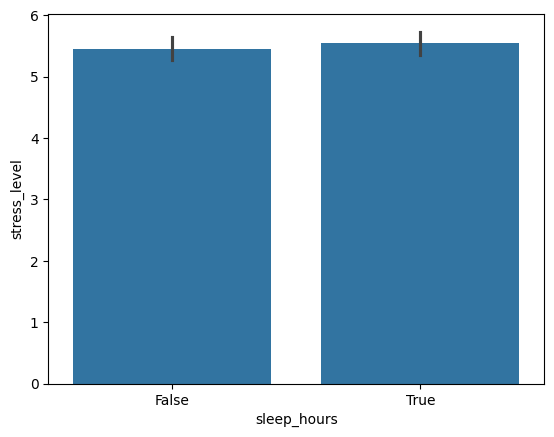

In [140]:
x = df['sleep_hours']>6
sns.barplot(df,x=x,y='stress_level')

In [141]:
df.groupby(by=x).agg({'stress_level':'mean'})

,stress_level
sleep_hours,
False,5.455457
True,5.544346


**Observation**

sleep hours affecting the stress level.

Does fast_food_frequency affect health_risk_score?

In [134]:
df.groupby(by='fast_food_frequency').agg({'health_risk_score':'mean'}).sort_values(by='health_risk_score',ascending=False)

,health_risk_score
fast_food_frequency,
High,57.741652
Medium,52.753994
Low,45.586777


**Observation**

more fast food frequency taken people heve high health risk score.

Which work_type has the highest health_risk_score?

In [120]:
df.groupby(by='work_type').agg({'health_risk_score':'mean'}).sort_values(by='health_risk_score',ascending=False)

,health_risk_score
work_type,
desk_job,52.861809
field_job,51.727700
REMOte,51.636029
hybrid,51.606481


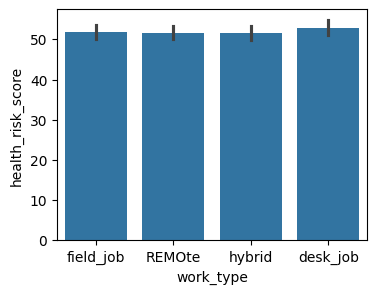

In [124]:
plt.figure(figsize=(4,3))
sns.barplot(df,x='work_type',y='health_risk_score')
plt.show()

**Observation**

compare all desk_job has more health risks 

How does age group affect health_risk_score?

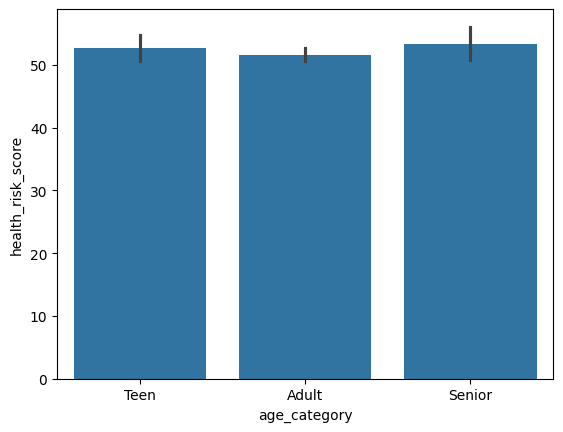

In [126]:
sns.barplot(df,x='age_category',y='health_risk_score')
plt.show()

In [128]:
df.groupby(by='age_category').agg({'health_risk_score':'mean'})

,health_risk_score
age_category,
Teen,52.617241
Adult,51.644961
Senior,53.307263


**Observation**

the Senior age category people more affect in health risk score. 

Do stress levels or health risks differ across genders?

In [129]:
df.groupby(by='gender').agg({'health_risk_score':'mean'})


,health_risk_score
gender,
Female,52.933007
Male,51.048611
Other,51.732026


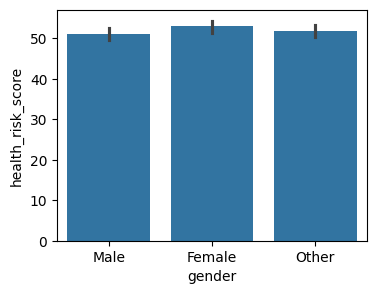

In [133]:
plt.figure(figsize=(4,3))
sns.barplot(df,x='gender',y='health_risk_score')
plt.show()

**Observation**

the more female has health risk score

Which Lifestyle Factor Impacts Health the Most?

In [138]:
df.corr(numeric_only=True)

,age,sleep_hours,exercise_days_per_week,social_media_hours,stress_level,health_risk_score
age,1.000000,-0.019184,0.037304,0.038731,-0.008793,0.001499
sleep_hours,-0.019184,1.000000,-0.005438,-0.001427,0.010600,-0.187914
exercise_days_per_week,0.037304,-0.005438,1.000000,0.013150,-0.015792,-0.223239
social_media_hours,0.038731,-0.001427,0.013150,1.000000,0.006571,0.420254
stress_level,-0.008793,0.010600,-0.015792,0.006571,1.000000,0.810583
health_risk_score,0.001499,-0.187914,-0.223239,0.420254,0.810583,1.000000


**Observation**

stress level affect the health risk it stongly correlated 

## Conclusion


Journalist occupation group have more average health risk score. Followed by Labaurer. 
More health risk score is have the south korea and followed by Germony, UAE, South Africa. 
the weekly seven days exercise decreasing the health risk score it creating a impact doing a exercise.
stress level affect the health risk it stongly correlated. gender by the female health risk and desk_job persons have risks.

more fast food frequency taken people heve high health risk score.